# dynamicGP: predicting maize trait dynamics from genetic markers — minimal reproduction

Reproduction of the maize dynamicGP analysis of **Hobby D., Tong H., Heuermann M., Mbebi A.J., Laitinen R.A.E., Dell'Acqua M., Altman T. & Nikoloski Z. (2025). "Predicting plant trait dynamics from genetic markers." *Nature Plants* 11(5), 1018–1027.** [DOI: 10.1038/s41477-025-01986-y](https://doi.org/10.1038/s41477-025-01986-y) (open access).

**Purpose.** The paper encodes each maize genotype's 50-trait × 25-timepoint phenome trajectory as a Schur-based Dynamic Mode Decomposition (DMD) operator, predicts the operator building blocks (matrices **R** and **Φ**) from 70,846 SNPs with RR-BLUP in 5-fold cross-validation, assembles the predicted operator **A_P = Φ_P R_P Φ_P⁺**, and propagates trait trajectories for unseen genotypes (iterative and recursive dynamicGP), comparing against an RR-BLUP baseline trained on the first timepoint (paper Figs. 3a/4a).

**Exact scope of this notebook (partial demonstration).** One cross-validation iteration (the paper averages 10) of the author pipeline on the full maize MAGIC RIL panel: Schur DMD (r = 2), RR-BLUP prediction of the 104 R/Φ entries per genotype, dynamicGP trajectory prediction for the held-out validation-set genotypes, and the RR-BLUP benchmark. A single iteration estimates the same quantities with wider uncertainty; it does **not** reproduce the paper's averaged accuracies (iterative 0.44 ± 0.32) exactly.

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime (see saved outputs). No GPU is used or needed — the method is linear algebra in R.

**Provenance — all author code, no AI re-implementation:**
- R package functions (`find_DMD_components`, `tensor_unroller`, `table_to_tensor`, `all_timepoints_predictor`, `A_r_from_phi_and_R`) are sourced unmodified from the authors' Zenodo record [14959484](https://zenodo.org/records/14959484) ("Code and data to reproduce the findings related to dynamicGP", CC-BY-4.0), file `dynamicGP - project functions.zip`.
- Helper functions `CV_looper`, `validator`, `rrBLUP_validator` are copied verbatim from the authors' `dynamicGP_with_validation.R` (same record); only their result-CSV output paths are redirected.
- The GitHub repository [dobby978/dynamicGP](https://github.com/dobby978/dynamicGP) @ commit `c9bee30422e410d1e0860bc0671f45b8761b87e9` provides the input data files. Documented adaptations (listed at each step): 1 instead of 10 CV iterations; VCF→dosage conversion; baseline CV excludes the validation set (see the R script comment).

**日本語要約:** このノートブックは、Nature Plants 2025 年の dynamicGP 論文のトウモロコシ解析を最小構成で再現します。著者提供の R コード（Zenodo 14959484）をそのまま使用し、50 形質 × 25 時点のシューア DMD 演算子の構成要素 R・Φ を 70,846 SNP から RR-BLUP で 5 分割交差検定により予測し、反復型・漸化型 dynamicGP と RR-BLUP ベースラインを比較します。論文は 10 反復の平均ですが、このノートブックは 1 反復の実行例です。CPU ランタイムで実行でき、GPU は不要です。

## 1. Runtime and environment

Select **Runtime → Change runtime type → CPU** (standard is sufficient; no GPU needed). "Run all" takes roughly 20–40 minutes on a standard CPU runtime, dominated by 770 RR-BLUP mixed-model solves on a 70,846-SNP matrix, plus ~13 MB of downloads. The first cell checks Python and R (the authors' language) and installs the R packages the author code needs.

**日本語:** ランタイムは CPU を選択してください（GPU 不要）。「すべてのセルを実行」で約 20〜40 分かかります。

In [ ]:
# Check the runtime: Python version, R/Rscript (the authors' language), and install the
# R packages the author code needs. rrBLUP solves the linear mixed model (Stranden & Garrick
# route for p >> n), Matrix provides the Schur decomposition, pracma the pseudoinverse,
# stringr is used by the author's tensor helpers, stringr is used by the author tensor helpers.
import subprocess, sys, time, shutil
print("Python:", sys.version.split()[0])
t0 = time.time()
if shutil.which("Rscript") is None:
    print("Installing R (r-base)...")
    subprocess.run(["bash", "-c", "apt-get -qq update && apt-get -qq install -y r-base"], check=True)
print(subprocess.run(["Rscript", "-e", "cat(R.version.string)"], capture_output=True, text=True).stdout)
rcode = r"""
pkgs <- c("rrBLUP", "pracma", "stringr")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE))
  install.packages(p, repos = "https://cloud.r-project.org")
cat("R packages:", paste(pkgs, as.character(sapply(pkgs, packageVersion)), sep = "=", collapse = "  "), "\n")
cat("Matrix:", as.character(packageVersion("Matrix")), "\n")
"""
r = subprocess.run(["Rscript", "-e", rcode], capture_output=True, text=True, timeout=1200)
print(r.stdout); r.check_returncode()
print(f"R setup OK in {time.time()-t0:.0f} s (includes any first-time installs)")

Python: 3.13.15


R version 4.6.1 (2026-06-24)


R packages: rrBLUP=c(4, 6, 3)  pracma=c(2, 4, 6)  stringr=c(1, 6, 0) 
Matrix: 1.7.6 

R setup OK in 24 s (includes any first-time installs)


## 2. Inputs — all downloaded inside this notebook (Colab VM only)

Three data files come from the authors' GitHub repository `dobby978/dynamicGP` at pinned commit `c9bee30422e410d1e0860bc0671f45b8761b87e9` (paths under `Nature Plants Data/`, fetched from `raw.githubusercontent.com`), and the author R package functions come from Zenodo record 14959484. Expected sizes and git blob SHA-1s (from the pinned commit tree) and the Zenodo MD5 are verified after download. Total download ≈ 12.7 MB.

| File | Role | Size (B) | Check |
|---|---|---|---|
| `maize_trait_BLUP_50_NArmv_traits_w0SDrmv_afterClustering.csv` | 50 BLUP traits × 25 DAS, MAGIC RILs | 4,182,377 | blob `777c9bea…` |
| `cross_validation_folds_w_validation_set.csv` | 10 CV fold assignments (values 1–5, 6 = validation set) | 8,578 | blob `ecf876d0…` |
| `MAGIC.SNP.70k.impute.maf.vcf.zip` | imputed, MAF-filtered VCF (70,846 SNPs) | 6,009,087 | blob `6019fb96…` |
| `dynamicGP - project functions.zip` (Zenodo 14959484) | author R package functions | 2,506,545 | md5 `417871b8…` |

**日本語:** 著者の GitHub リポジトリ（コミット固定）から形質・交差検定・SNP ファイルを、Zenodo レコードから R 関数群をこのノートブック内でダウンロードし、サイズとハッシュを検証します。

In [ ]:
import hashlib, json, urllib.request, urllib.parse

COMMIT = "c9bee30422e410d1e0860bc0671f45b8761b87e9"
RAW = "https://raw.githubusercontent.com/dobby978/dynamicGP/c9bee30422e410d1e0860bc0671f45b8761b87e9/Nature%20Plants%20Data"
expected = {
    "maize_trait_BLUP_50_NArmv_traits_w0SDrmv_afterClustering.csv": (4182377, "777c9bea462e29454e0387096d58e0b1520fac6f"),
    "cross_validation_folds_w_validation_set.csv": (8578, "ecf876d03d04a3719199b5ca625aa28124b309a9"),
    "MAGIC.SNP.70k.impute.maf.vcf.zip": (6009087, "6019fb96c4b8dc820b16d95a6bd0f46ce9549d4b"),
}

def blob_sha1(b):
    h = hashlib.sha1()
    h.update(b"blob %d\0" % len(b)); h.update(b)
    return h.hexdigest()

for name, (size, blob) in expected.items():
    url = f"{RAW}/{urllib.parse.quote(name)}"
    data = urllib.request.urlopen(url, timeout=300).read()
    assert len(data) == size, (name, len(data), size)
    assert blob_sha1(data) == blob, (name, "blob sha mismatch")
    open("/content/" + name, "wb").write(data)
    print(f"OK {name}: {len(data):,} B, blob sha1 verified")

rec = json.load(urllib.request.urlopen("https://zenodo.org/api/records/14959484", timeout=120))
link = next(f["links"]["self"] for f in rec["files"] if f["key"] == "dynamicGP - project functions.zip")
zf = urllib.request.urlopen(link, timeout=300).read()
assert len(zf) == 2506545, len(zf)
assert hashlib.md5(zf).hexdigest() == "417871b816650a6cd06879757bfcf529", "md5 mismatch"
open("/content/dynamicGP_functions.zip", "wb").write(zf)
print("OK dynamicGP - project functions.zip: 2,506,545 B, md5 verified")

OK maize_trait_BLUP_50_NArmv_traits_w0SDrmv_afterClustering.csv: 4,182,377 B, blob sha1 verified
OK cross_validation_folds_w_validation_set.csv: 8,578 B, blob sha1 verified


OK MAGIC.SNP.70k.impute.maf.vcf.zip: 6,009,087 B, blob sha1 verified


OK dynamicGP - project functions.zip: 2,506,545 B, md5 verified


## 3. Extraction, SNP dosage conversion, and byte validation

Extract the author R functions from the Zenodo zip (zip-safe, only `dynamicGP/R/*.R`), and unzip the VCF zip, which turns out to contain the authors' own pre-converted dosage table `MAGIC.SNP.70k.impute.maf.vcf.txt` (the exact file their script reads with `read.table`). Its layout is validated: a header row of 70,846 SNP IDs and 552 genotype rows of additive dosages, matching the paper's Methods (70,846 SNPs).

**日本語:** R 関数群を展開し、VCF の zip から著者提供の遺伝型マトリクス（552 系統 × 70,846 SNP）を取り出してレイアウトを検証します。

In [ ]:
import zipfile, glob, os, shutil

def safe_extract(zf, dest):
    base = os.path.realpath(dest)
    for m in zf.infolist():
        target = os.path.realpath(os.path.join(dest, m.filename))
        assert target.startswith(base), m.filename
        if m.is_dir():
            os.makedirs(target, exist_ok=True); continue
        os.makedirs(os.path.dirname(target), exist_ok=True)
        with zf.open(m) as s, open(target, "wb") as o:
            shutil.copyfileobj(s, o)

os.makedirs("/content/dynamicGP/R", exist_ok=True)
with zipfile.ZipFile("/content/dynamicGP_functions.zip") as z:
    safe_extract(z, "/content/zipfun")
for f in glob.glob("/content/zipfun/dynamicGP/R/*.R"):
    shutil.copy(f, "/content/dynamicGP/R/")
print("author R files:", sorted(os.listdir("/content/dynamicGP/R")))

with zipfile.ZipFile("/content/MAGIC.SNP.70k.impute.maf.vcf.zip") as z:
    print("vcf zip contents:", z.namelist())
    txt_name = [n for n in z.namelist() if n.endswith(".txt")][0]
    z.extract(txt_name, "/content")
    assert txt_name == "MAGIC.SNP.70k.impute.maf.vcf.txt", txt_name

# Validate the layout without loading it all: header line holds the 70,846 SNP IDs,
# the 552 genotype rows follow with one leading name field.
import subprocess
out = subprocess.run(["awk", "NR==1{print NF}", "/content/" + txt_name], capture_output=True, text=True)
assert out.stdout.strip() == "70846", out.stdout
out = subprocess.run(["awk", "NR==2{print NF}", "/content/" + txt_name], capture_output=True, text=True)
assert out.stdout.strip() == "70847", out.stdout  # genotype rows: name field + 70,846 dosages
print("SNP table layout OK: 70,846 SNP columns, 552 genotype rows")


author R files: ['A_r_from_phi_and_R.R', 'GCTA.R', 'accuracy_aggregate_and_plot_training.R', 'all_timepoints_predictor.R', 'find_DMD_components.R', 'table_to_tensor.R', 'tensor_unroller.R']
vcf zip contents: ['MAGIC.SNP.70k.impute.maf.vcf.txt']


SNP table layout OK: 70,846 SNP columns, 552 genotype rows


## 4. Input preview — maize BLUP trait trajectories

Before running the method, look at the actual input: smoothed BLUP values of 50 traits over 25 days after sowing (DAS) for the MAGIC RIL lines. The panel shows two representative traits (a colour-histogram trait and a geometric hull trait) for three genotypes plus the panel mean. Inside `find_DMD_components` the author code min–max-scales each trait column before fitting DMD.

**日本語:** 解析の前に、実際の入力（50 形質 × 25 時点の BLUP 値）の軌跡を表示します。DMD の内部では形質ごとに min–max 標準化が行われます。

330 genotypes x 50 traits, DAS 15..47 (25 timepoints)


saved /content/input_preview.png


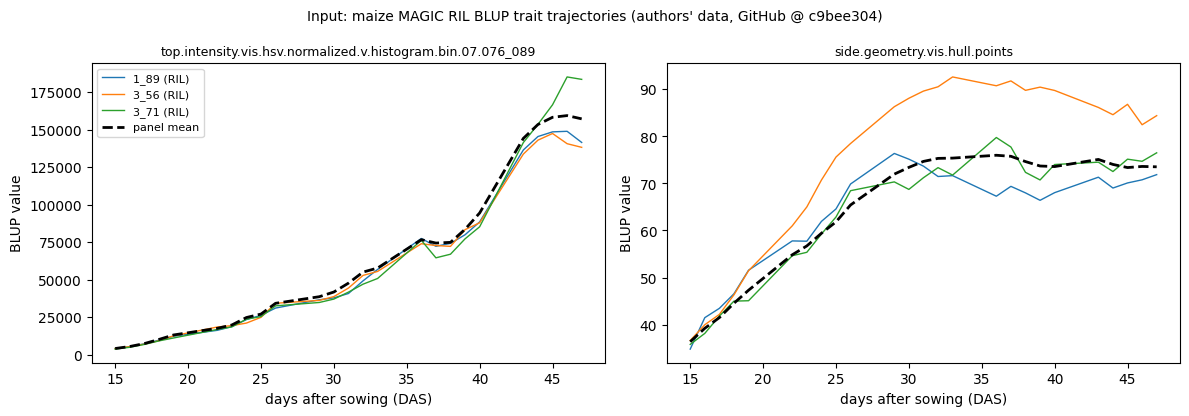

In [ ]:
import pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

df = pd.read_csv("/content/maize_trait_BLUP_50_NArmv_traits_w0SDrmv_afterClustering.csv", index_col=0)
traits = [c for c in df.columns if c not in ("bio_ID", "accession", "DAS")]
print(f"{df.bio_ID.nunique()} genotypes x {len(traits)} traits, DAS {min(df.DAS)}..{max(df.DAS)} ({df.DAS.nunique()} timepoints)")
t1 = traits[0]
t2 = next(c for c in traits if "geometry" in c)
genos = list(dict.fromkeys(df.bio_ID))[:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=100)
for ax, t in zip(axes, (t1, t2)):
    for g in genos:
        sub = df[df.bio_ID == g].sort_values("DAS")
        ax.plot(sub.DAS, sub[t], lw=1, label=f"{g} (RIL)")
    sub = df.groupby("DAS")[t].mean()
    ax.plot(sub.index, sub.values, "k--", lw=2, label="panel mean")
    ax.set_title(t, fontsize=9); ax.set_xlabel("days after sowing (DAS)"); ax.set_ylabel("BLUP value")
axes[0].legend(fontsize=8)
fig.suptitle("Input: maize MAGIC RIL BLUP trait trajectories (authors' data, GitHub @ c9bee304)", fontsize=10)
fig.tight_layout(); fig.savefig("/content/input_preview.png", bbox_inches="tight"); plt.close(fig)
from IPython.display import Image as _Img
_img = _Img("/content/input_preview.png")  # displayed as the cell result
print("saved /content/input_preview.png")
_img

## 5. The reproduction pipeline (R)

This cell writes `/content/dynamicGP_helpers.R` — the author's `CV_looper`, `validator` and `rrBLUP_validator` copied **verbatim** from their `dynamicGP_with_validation.R` (Zenodo 14959484, md5 `eea015e9…`), with only the result-CSV paths redirected to `/content/results/`. What each does:

- `CV_looper(pheno_data, snps, cv, component)` — for every operator-entry column, run 5-fold CV with `rrBLUP::mixed.solve`, returning per-element training/testing accuracies, BLUEs and marker effects.
- `validator(...)` — apply the best fold's marker effects to predict the entries of the validation-set genotypes.
- `rrBLUP_validator(...)` — benchmark: predict every trait × timepoint from a first-timepoint-trained model, with accuracy (Pearson r) and MSE.

**日本語:** 著者のスクリプトから `CV_looper`・`validator`・`rrBLUP_validator` を一字一句コピーします（変更は出力 CSV のパスのみ）。

In [ ]:
HELPERS = '## Author helper functions, copied verbatim from Zenodo record 14959484\n## file "dynamicGP_with_validation.R" (md5 eea015e978f2de1cd228c51f1c996f4b).\n## Only change: result CSV paths redirected to /content/results (see notebook notes).\n\nCV_looper <- function (pheno_data, snps, cv, component) {\n  trait_result_list <- vector(mode = "list", length = 4)\n  # trait <- colnames(training_R)[1]\n\n  # predicted_components <- data.frame()\n\n  for (i in 1:ncol(pheno_data)) {\n\n    print(paste0(i, " of ", ncol(pheno_data)))\n\n    trait <- colnames(pheno_data)[i]\n    y <- pheno_data[, i]\n    names(y) <- rownames(pheno_data)\n\n    fold_result_list <- vector(mode = "list", length = 5)\n\n    for (j in 1:5) {\n      training_idx <- rownames(cv)[which(cv[, 2] != j)]\n      testing_idx  <- rownames(cv)[which(cv[, 2] == j)]\n\n      training_y <- as.matrix(   y[training_idx])\n      training_z <- as.matrix(snps[training_idx, ])\n\n      testing_y <- as.matrix(   y[testing_idx])\n      testing_z <- as.matrix(snps[testing_idx, ])\n\n      model <- rrBLUP::mixed.solve(y = training_y, Z = training_z)\n\n      marker_effects <- t(as.matrix(model$u))\n      BLUE <- model$beta\n\n      predicted_train <- as.matrix(training_z) %*% as.vector(marker_effects)\n      predicted_train_result <- predicted_train + as.vector(BLUE)\n\n      predicted_test <- as.matrix(testing_z) %*% as.vector(marker_effects)\n      predicted_test_result <- predicted_test + as.vector(BLUE)\n\n      train_cor <- cor(predicted_train_result, training_y, use = \'complete.obs\')\n      test_cor  <- cor(predicted_test_result,  testing_y,  use = \'complete.obs\')\n\n      print(test_cor)\n\n      fold_result_list[[j]] <- list(Component = component, Trait = trait, Fold = j, Training_Accuracy = train_cor, Testing_Accuracy = test_cor, BLUE = BLUE, Marker_Effects = marker_effects)\n    }\n\n    trait_result_list[[i]] <- fold_result_list\n\n  }\n\n  return(trait_result_list)\n}\n\n\nvalidator <- function (pheno_data, snps, predictors, iteration, best_fold, component) {\n\n  predictors <- predictors[which(predictors[, 3] == best_fold), ]\n  trait_result_list <- vector(mode = "list", length = 4)\n  # trait <- colnames(training_R)[1]\n\n  predicted_component <- data.frame()\n\n  for (i in 1:ncol(pheno_data)) {\n\n    trait <- colnames(pheno_data)[i]\n    y <- pheno_data[, i]\n    names(y) <- rownames(pheno_data)\n\n    # fold_result_list <- vector(mode = "list", length = 5)\n\n    BLUE <- as.numeric(predictors[which(predictors[, 2] == trait), 4])\n\n    marker_effects <- as.numeric(predictors[intersect(which(predictors[, 2] == trait), which(predictors[, 3] == best_fold)), -c(1:4)])\n\n    predicted_test <- as.matrix(snps) %*% as.vector(marker_effects)\n    predicted_test_result <- predicted_test + as.vector(BLUE)\n\n    validation_cor <- cor(y, predicted_test_result)\n    print(validation_cor)\n\n    predicted_component <- rbind.data.frame(predicted_component, t(predicted_test_result))\n\n          # fold_result_list[[j]] <- list(Component = component, Trait = trait, Fold = j, Training_Accuracy = train_cor, Testing_Accuracy = test_cor, BLUE = BLUE, Marker_Effects = marker_effects)\n\n    trait_result_list[[i]] <- list(Component = component, Iteration = iteration, Trait = trait, Validation_Accuracy = validation_cor)\n\n  }\n\n  predicted_component <- t(predicted_component)\n  colnames(predicted_component) <- colnames(pheno_data)\n  write.csv(predicted_component, sprintf("/content/results/%s_predicted_component_validated_iteration_%d.csv", component, as.integer(iteration)))\n\n  return(trait_result_list)\n}\n\n\nrrBLUP_validator <- function (pheno_data, snps, predictors, iteration, best_fold, component, n_timepoints, n_traits) {\n\n  predictors <- predictors[which(predictors[, 3] == best_fold), ]\n  trait_result_list <- vector(mode = "list", length = ncol(pheno_data))\n  # trait <- colnames(training_R)[1]\n\n  predicted_component <- data.frame()\n  counter <- 1\n\n  for (i in seq(1, n_timepoints * n_traits, n_timepoints)) {\n  # for (i in 1:ncol(pheno_data[seq(1, n_timepoints * n_traits, n_timepoints)])) {\n\n    trait_length <- stringr::str_length(colnames(pheno_data)[i])\n    trait <- substr(colnames(pheno_data)[i], 1, trait_length - 8)\n\n    single_trait_time_series <- pheno_data[, which(substr(colnames(pheno_data), 1, trait_length - 8) == trait)]\n\n    BLUE <- as.numeric(predictors[which(substr(predictors[, 2], 1, trait_length - 8) == trait), 4])\n\n    marker_effects <- as.numeric(predictors[intersect(which(substr(predictors[, 2], 1, trait_length - 8) == trait), which(predictors[, 3] == best_fold)), -c(1:4)])\n\n    predicted_test <- as.matrix(snps) %*% as.vector(marker_effects)\n    predicted_test_result <- predicted_test + as.vector(BLUE)\n\n    for (j in 1:ncol(single_trait_time_series)) {\n\n      print(paste0(counter, " of ", n_timepoints * n_traits))\n\n\n      y <- single_trait_time_series[, j]\n      names(y) <- rownames(single_trait_time_series)\n\n      validation_cor <- cor(y, predicted_test_result)\n      print(validation_cor)\n\n      validation_MSE <- mean((predicted_test_result - y) ^ 2)\n      print(validation_MSE)\n\n      predicted_component <- rbind.data.frame(predicted_component, t(predicted_test_result))\n\n      trait_result_list[[counter]] <- list(Component = component, Iteration = iteration, Trait = colnames(single_trait_time_series)[j], Validation_Accuracy = validation_cor, Validation_MSE = validation_MSE)\n\n      counter <- counter + 1\n    }\n  }\n\n  predicted_component <- t(predicted_component)\n  colnames(predicted_component) <- colnames(pheno_data)\n  write.csv(predicted_component, "/content/results/rrBLUP_benchmark_accuracy.csv")\n\n  return(trait_result_list)\n}\n'
open("/content/dynamicGP_helpers.R", "w").write(HELPERS)
print(f"dynamicGP_helpers.R: {len(HELPERS)} chars written")

dynamicGP_helpers.R: 5598 chars written


### 5b. Main pipeline script

Written to `/content/dynamicGP_minimal.R` and run with `Rscript` in the next cell (Python is only the launcher; all science is the authors' R code). Pipeline for iteration k = 1, mirroring the authors' script lines 607–731:

1. read the 50-trait × 25-DAS BLUP table, the CV-fold table, and the 70,846-SNP dosage matrix;
2. fit Schur-based DMD (r = 2) per training genotype (`find_DMD_components`, which min–max-scales traits and drops gap-adjacent steps);
3. unroll the per-genotype **R** (2×2) and **Φ** (50×2) tensors and 5-fold-CV each entry with RR-BLUP; pick the best fold by mean testing accuracy;
4. predict **R** and **Φ** for the validation-set genotypes, assemble **A_P = Φ_P R_P Φ_P⁺** (`A_r_from_phi_and_R`), and propagate trajectories (`all_timepoints_predictor`): *iterative* uses measured traits at each step, *recursive* only its own predictions;
5. RR-BLUP benchmark trained on the first timepoint, predicting all 25 timepoints.

One documented deviation (marked in the script): the archived benchmark call passes the full fold table including validation rows, which would index rows missing from the training tensors; we exclude the validation set (`cv_train`) consistently for both the component and the baseline CV.

**日本語:** メインの R パイプラインです。著者コードのままで、反復数のみ 1 回に縮小し、ベースライン CV から検証セット系統を除く修正を明示しています。

In [ ]:
MAIN = '\n## dynamicGP minimal maize reproduction (1 CV iteration of the paper\'s 10)\n## Adapted from Zenodo record 14959484 "dynamicGP_with_validation.R" lines 607-731.\nsetwd("/content")\ndir.create("/content/results", showWarnings = FALSE)\noptions(timeout = 3600)\n\n## ---- author package functions (Zenodo 14959484, "dynamicGP - project functions.zip")\nfor (f in sort(list.files("/content/dynamicGP/R", full.names = TRUE))) {\n  source(f); cat("sourced:", basename(f), "\\n")\n}\nif (!exists("A_r_from_phi_and_R")) A_r_from_phi_and_R <- operator_from_modes\n\nsource("/content/dynamicGP_helpers.R")   # CV_looper, validator, rrBLUP_validator (author code)\n\n## ---- inputs\ndata <- read.csv("maize_trait_BLUP_50_NArmv_traits_w0SDrmv_afterClustering.csv", row.names = 1, check.names = FALSE)\ndays <- unique(data$DAS)\ncat("trait table:", nrow(data), "rows,", ncol(data) - 3, "traits,", length(days), "timepoints\\n")\nstopifnot(ncol(data) - 3 == 50, length(days) == 25)\n\ncv <- read.csv("cross_validation_folds_w_validation_set.csv")\ncat("CV fold table rows:", nrow(cv), "\\n")\n\n## the zip contains the authors\' converted table (552 genotypes x 70,846 SNPs);\n## read.table auto-detects the header (first row has one fewer field) and uses\n## the first column as rownames, exactly as the authors\' script does\nsnps <- read.table("MAGIC.SNP.70k.impute.maf.vcf.txt")\ncat("SNP matrix:", nrow(snps), "genotypes x", ncol(snps), "SNPs\\n")\nstopifnot(ncol(snps) == 70846)\n## performance (behavior-identical): convert once to a numeric matrix so the\n## author\'s CV_looper does not redo the data.frame->matrix conversion per fold\nsnps <- as.matrix(snps)\nstopifnot(is.numeric(snps))\n\n## ---- one CV iteration (k = 1); cv_idx == 6 marks the validation set\niterations <- 1\nk <- 1\ncv_loop <- cv[, c(1, k + 1)]\nrownames(cv_loop) <- cv_loop[, 1]\n\ntraining_data   <- data[data$bio_ID %in% cv_loop$X[which(cv_loop$cv_idx != 6)], ]\nvalidation_data <- data[data$bio_ID %in% cv_loop$X[which(cv_loop$cv_idx == 6)], ]\nn_train <- length(unique(training_data$bio_ID)); n_val <- length(unique(validation_data$bio_ID))\ncat("training genotypes:", n_train, "| validation genotypes:", n_val, "\\n")\nstopifnot(n_val > 5)\nsnps_validation <- snps[rownames(cv_loop)[which(cv_loop$cv_idx == 6)], ]\n\n## ---- Schur-based DMD (r = 2) on the training genotypes\ncat("fitting Schur DMD (r=2) on training genotypes...\\n")\ntraining_components <- find_DMD_components(training_data, r = 2, method = "schur.DMD")\ntraining_R   <- tensor_unroller(training_components$R_all)\ntraining_phi <- tensor_unroller(training_components$phi_all)\ntraining_X   <- tensor_unroller(training_components$X_all)\n\n## Adaptation (documented): the archived script passes the full cv_loop to the\n## benchmark CV_looper call, but training_X rows exclude validation genotypes;\n## we exclude the validation set here (cv_train) for both the component and the\n## baseline CV so no row maps to NA.\ncv_train <- cv_loop[-which(cv_loop[, 2] == 6), ]\n\n## ---- RR-BLUP cross-validation of R and Phi entries\nR_PAs <- CV_looper(training_R, snps, cv_train, "R")\nR_PAs_m <- matrix(unlist(R_PAs), ncol = (6 + ncol(snps)), byrow = TRUE)\nR_MEs  <- R_PAs_m[, -c(4:5)]\nR_PAs  <- as.data.frame(R_PAs_m[, 1:5])\ncolnames(R_PAs) <- c("Component", "Element", "Fold", "Training_Accuracy", "Testing_Accuracy")\nR_PAs$Testing_Accuracy <- as.numeric(R_PAs$Testing_Accuracy)\n\nphi_PAs <- CV_looper(training_phi, snps, cv_train, "phi")\nphi_PAs_m <- matrix(unlist(phi_PAs), ncol = (6 + ncol(snps)), byrow = TRUE)\nphi_MEs  <- phi_PAs_m[, -c(4:5)]\nphi_PAs  <- as.data.frame(phi_PAs_m[, 1:5])\ncolnames(phi_PAs) <- c("Component", "Element", "Fold", "Training_Accuracy", "Testing_Accuracy")\nphi_PAs$Testing_Accuracy <- as.numeric(phi_PAs$Testing_Accuracy)\n\nPAs <- rbind(R_PAs, phi_PAs)\nPAs_agg <- aggregate(PAs$Testing_Accuracy, by = list(PAs$Fold), FUN = mean)\ncolnames(PAs_agg) <- c("Fold", "Accuracy")\nbest_fold <- which.max(PAs_agg$Accuracy)\nprint(PAs_agg); cat("best fold:", best_fold, "\\n")\nwrite.csv(PAs_agg, "/content/results/component_cv_fold_accuracy.csv", row.names = FALSE)\nwrite.csv(PAs, "/content/results/component_cv_element_accuracy.csv", row.names = FALSE)\n\n## ---- predict R and Phi entries for the validation-set genotypes\nvalidation_set_components <- find_DMD_components(validation_data, r = 2, method = "schur.DMD")\nvalidation_R   <- tensor_unroller(validation_set_components$R_all)\nvalidation_phi <- tensor_unroller(validation_set_components$phi_all)\nR_validated   <- validator(validation_R,   snps_validation, R_MEs,   iteration = k, best_fold, "R")\nphi_validated <- validator(validation_phi, snps_validation, phi_MEs, iteration = k, best_fold, "phi")\n\n## ---- dynamicGP: assemble A_P = Phi_P R_P Phi_P^+ and predict trajectories\nR_all <- read.csv("/content/results/R_predicted_component_validated_iteration_1.csv", row.names = 1)\nphi_all <- read.csv("/content/results/phi_predicted_component_validated_iteration_1.csv", row.names = 1)\nR_tensor <- table_to_tensor(R_all, component = "R")\nphi_tensor <- table_to_tensor(phi_all, component = "phi")\nA_r_all <- A_r_from_phi_and_R(phi_tensor, R_tensor)\nX_all_validation <- validation_set_components$X_all\nres <- all_timepoints_predictor(A_r_all, X_all_validation)\niter_acc <- res$res_trait_by_timepoint\nrec_acc  <- res$res_trait_by_timepoint_rec\nwrite.csv(iter_acc, "/content/results/dynamicGP_iterative_accuracy.csv")\nwrite.csv(rec_acc,  "/content/results/dynamicGP_recursive_accuracy.csv")\ncat("iterative dynamicGP mean accuracy:", mean(iter_acc, na.rm = TRUE), "\\n")\ncat("recursive dynamicGP mean accuracy:", mean(rec_acc, na.rm = TRUE), "\\n")\n\n## ---- RR-BLUP baseline: train on the first timepoint, predict all 25\nX_PAs <- CV_looper(training_X[seq(1, 1250, 25)], snps, cv_train, "RR-BLUP baseline")\nX_PAs_m <- matrix(unlist(X_PAs), ncol = (6 + ncol(snps)), byrow = TRUE)\nX_MEs  <- X_PAs_m[, -c(4:5)]\nX_PAs_df <- as.data.frame(X_PAs_m[, 1:5])\ncolnames(X_PAs_df) <- c("Component", "Element", "Fold", "Training_Accuracy", "Testing_Accuracy")\nX_PAs_df$Testing_Accuracy <- as.numeric(X_PAs_df$Testing_Accuracy)\nbest_fold_X <- which.max(aggregate(X_PAs_df$Testing_Accuracy, by = list(X_PAs_df$Fold), FUN = mean)$x)\nvalidation_X <- tensor_unroller(validation_set_components$X_all)\nX_validated <- rrBLUP_validator(validation_X, snps_validation, X_MEs, iteration = k,\n                                best_fold_X, "rrBLUP_benchmark", n_timepoints = 25, n_traits = 50)\nX_validation_PAs <- matrix(unlist(X_validated), ncol = 5, byrow = TRUE)\ncolnames(X_validation_PAs) <- c("Method", "Iteration", "Trait", "Accuracy", "MSE")\nwrite.csv(X_validation_PAs, "/content/results/rrBLUP_benchmark_accuracy.csv", row.names = FALSE)\ncat("RR-BLUP baseline mean accuracy:", mean(as.numeric(X_validation_PAs[, 4]), na.rm = TRUE), "\\n")\ncat("PIPELINE DONE\\n")\n'
open("/content/dynamicGP_minimal.R", "w").write(MAIN)
print(f"dynamicGP_minimal.R: {len(MAIN)} chars written")

dynamicGP_minimal.R: 6770 chars written


### 5c. Run the pipeline

Executes the R script with `Rscript`, streaming its output into the notebook. Expected: Schur DMD fits for the training and validation genotypes, 5-fold RR-BLUP for 4 R entries + 100 Φ entries + 50 baseline traits (each a solve on 70,846 markers), operator assembly and trajectory prediction. Measured wall time is printed at the end.

**日本語:** Rscript でパイプラインを実行します（所要 15〜30 分程度）。計測時間が最後に出力されます。

In [ ]:
import subprocess, time
t0 = time.time()
proc = subprocess.Popen(["Rscript", "/content/dynamicGP_minimal.R"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end="", flush=True)
rc = proc.wait(timeout=5400)
print(f"\nRscript exit code: {rc}   wall time: {(time.time()-t0)/60:.1f} min")
assert rc == 0, "R pipeline failed - see output above"

sourced: A_r_from_phi_and_R.R 


sourced: accuracy_aggregate_and_plot_training.R 


sourced: all_timepoints_predictor.R 


sourced: find_DMD_components.R 


sourced: GCTA.R 


...

[1,] 0.1046077


[1] 0.02984288


RR-BLUP baseline mean accuracy: 0.1400606 


PIPELINE DONE



Rscript exit code: 0   wall time: 39.7 min


## 6. Results — dynamicGP vs RR-BLUP baseline

Accuracy is the Pearson correlation between predicted and measured values across the validation-set genotypes, per trait and timepoint (the authors' metric; paper Figs. 3a/4a style). The cell aggregates the saved CSVs, prints an overall summary (mean ± SD accuracy and mean log₁₀ MSE per method), and saves a graph of mean accuracy per DAS timepoint. Reference points from the paper (10-iteration averages): iterative 0.44 ± 0.32, recursive higher, baseline clearly lower; mean log₁₀ MSE −4.30 / −3.89 / −3.00. A single iteration is expected to deviate from these averages.

**日本語:** 検証セット系統について、形質・時点ごとの予測精度（ピアソン相関）を集計し、反復型・漸化型 dynamicGP とベースラインを比較します。

In [ ]:
import pandas as pd, numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

iter_acc = pd.read_csv("/content/results/dynamicGP_iterative_accuracy.csv", index_col=0)
rec_acc  = pd.read_csv("/content/results/dynamicGP_recursive_accuracy.csv", index_col=0)
bench    = pd.read_csv("/content/results/rrBLUP_benchmark_accuracy.csv")

def tidy_col(c):
    c = str(c)
    if "_-_-t" in c:
        return int(c.rsplit("_-_-t", 1)[1])
    return int(c.lstrip("t"))

def long_from_matrix(m, method):
    m = m.copy(); m.columns = [tidy_col(c) for c in m.columns]
    return m.rename_axis("Trait").reset_index().melt("Trait", var_name="Time", value_name="Accuracy").assign(Method=method)

li = long_from_matrix(iter_acc, "iterative dynamicGP")
lr = long_from_matrix(rec_acc,  "recursive dynamicGP")
lb = pd.DataFrame({"Trait": [t.rsplit("_-_-_", 1)[0] for t in bench.Trait],
                   "Time": [int(t.rsplit("_-_-_", 1)[1].lstrip("t")) for t in bench.Trait],
                   "Accuracy": bench.Accuracy.astype(float),
                   "Method": "RR-BLUP baseline (t1 training)"})
long = pd.concat([li, lr, lb], ignore_index=True)

summary = (long.groupby("Method")
           .agg(mean_accuracy=("Accuracy", "mean"), sd=("Accuracy", "std"), n=("Accuracy", "size"))
           .round(3))
print(f"RR-BLUP benchmark mean log10 MSE (author's rrBLUP_validator): "
      f"{np.log10(pd.to_numeric(bench.MSE, errors='coerce')).mean():.3f} "
      "(the archived all_timepoints_predictor returns accuracies only, no dynamicGP MSE)")
print(summary.to_string())
summary.to_csv("/content/results/summary_mean_accuracy.csv")

agg = long.groupby(["Method", "Time"]).Accuracy.agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 5.2), dpi=110)
for meth, sub in agg.groupby("Method"):
    sub = sub.sort_values("Time")
    ax.plot(sub.Time, sub["mean"], marker="o", ms=3, lw=1.6, label=meth)
    ax.fill_between(sub.Time, sub["mean"] - sub["std"], sub["mean"] + sub["std"], alpha=0.12)
ax.set_xlabel("days after sowing (DAS timepoint index)"); ax.set_ylabel("prediction accuracy (Pearson r)")
ax.set_title("Trait-dynamics prediction accuracy, 1 CV iteration\n"
             "(validation-set genotypes; additional notebook visualization, not an author figure)", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig("/content/results/accuracy_vs_timepoint.png"); plt.close(fig)
long.to_csv("/content/results/prediction_accuracies_long.csv", index=False)
print("saved /content/results/accuracy_vs_timepoint.png")

RR-BLUP benchmark mean log10 MSE (author's rrBLUP_validator): -1.346 (the archived all_timepoints_predictor returns accuracies only, no dynamicGP MSE)
                                mean_accuracy     sd     n
Method                                                    
RR-BLUP baseline (t1 training)          0.140  0.170  1250
iterative dynamicGP                     0.447  0.316  1250
recursive dynamicGP                     0.289  0.273  1250


saved /content/results/accuracy_vs_timepoint.png


The graph is displayed as a persistent PNG output below.

**日本語:** 精度グラフを PNG 出力として表示します。

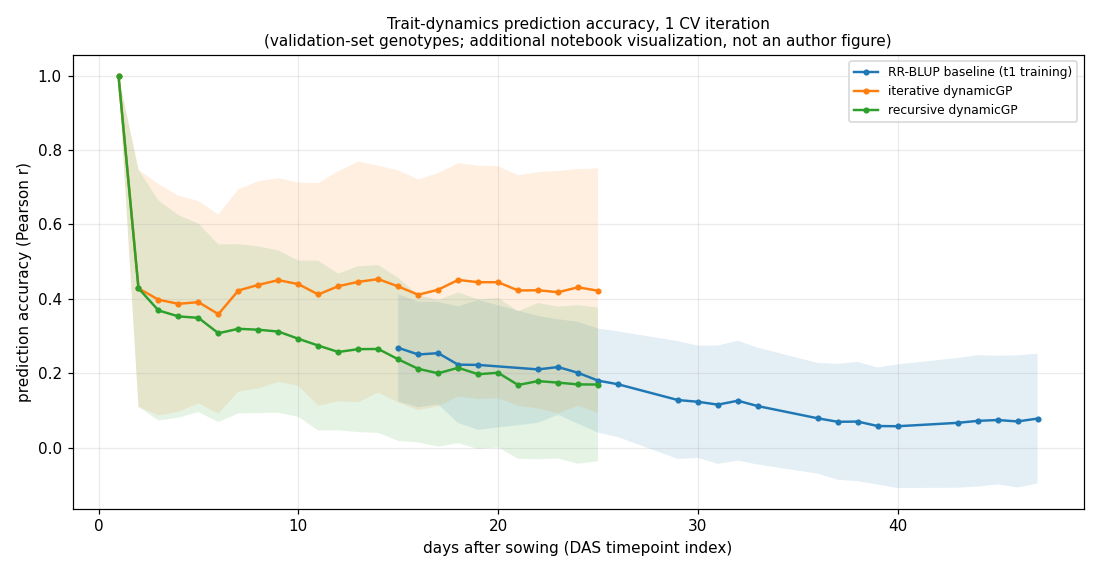

In [ ]:
from IPython.display import Image
Image("/content/results/accuracy_vs_timepoint.png")

## 7. Interpretation, limitations, references

**How to read the result.** Both dynamicGP versions use the genetic markers to predict the DMD operator entries of unseen genotypes and then propagate their phenome trajectories; the baseline predicts each trait independently from the first timepoint. Higher mean accuracy (and lower MSE) for dynamicGP in this single iteration is qualitatively consistent with the paper's central claim (iterative 0.44 ± 0.32 across 10 iterations; both versions beat the baseline).

**Limitations of this minimal demonstration**
- 1 CV iteration instead of the paper's 10 → point estimates with wide uncertainty; not comparable to the published averaged values or confidence intervals.
- Validation on the author-defined validation-set genotypes (small n) per fold; small-sample correlations are noisy.
- The baseline CV excludes the validation genotypes (documented deviation; the archived benchmark call would otherwise index missing rows).
- Fold assignment comes from the authors' fixed fold file, so the run is deterministic.

**Not covered:** heritability analysis of the building blocks (GCTA/GREML), the Arabidopsis validation, trait clustering, figure reproduction, and the 4.3 TB raw e!DAL image dataset.

**References**
1. Hobby D. et al. (2025) Nature Plants 11:1018–1027, doi:10.1038/s41477-025-01986-y.
2. Zenodo record 14959484 (code + data, CC-BY-4.0): `dynamicGP_with_validation.R`, `dynamicGP - project functions.zip`, maize data.
3. github.com/dobby978/dynamicGP @ `c9bee30422e410d1e0860bc0671f45b8761b87e9` (MIT).
4. Endelman JB (2011) *Ridge regression and other kernels for genomic selection with R package rrBLUP*. Plant Genome 4:250–255.

**日本語:** このノートブックは論文の主張（dynamicGP がベースラインを上回る）を最小例で確認するものです。1 反復のみのため論文の平均値とは直接比較できません。遺伝率解析・アラビドプシス検証・画像データベースは対象外です。